In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/inventory.csv')

df.head()

,RegionName,CountryName,State,City,PostalCode,WarehouseAddress,WarehouseName,EmployeeName,EmployeeEmail,EmployeePhone,...,CustomerName,CustomerAddress,CustomerCreditLimit,CustomerEmail,CustomerPhone,Status,OrderDate,OrderItemQuantity,PerUnitPrice,TotalItemQuantity
0,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Summer Payne,summer.payne@example.com,5151238181,...,Flor Stone,2904 S Salina St,5000,flor.stone@raytheon.com,13171234104,Shipped,17-Nov-16,132,469.99,122
1,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Rose Stephens,rose.stephens@example.com,5151238080,...,Lavera Emerson,"5344 Haverford Ave, Philadelphia",5000,lavera.emerson@plainsallamerican.com,13171234111,Shipped,20-Feb-17,124,519.99,123
2,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Annabelle Dunn,annabelle.dunn@example.com,5151234444,...,Fern Head,"1795 Wu Meng, Muang Chonburi",1200,fern.head@usfoods.com,18121234115,Canceled,03-Jan-17,92,800.74,123
3,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Tommy Bailey,tommy.bailey@example.com,5151234567,...,Shyla Ortiz,"Walpurgisstr 69, Munich",2400,shyla.ortiz@abbvie.com,13171234126,Pending,15-Oct-17,128,849.99,124
4,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Blake Cooper,blake.cooper@example.com,5151234569,...,Jeni Levy,"Via Frenzy 6903, Roma",1200,jeni.levy@centene.com,18121214129,Shipped,09-Apr-17,106,109.99,125


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Rows: 400
Columns: 28

Column Names:
['RegionName', 'CountryName', 'State', 'City', 'PostalCode', 'WarehouseAddress', 'WarehouseName', 'EmployeeName', 'EmployeeEmail', 'EmployeePhone', 'EmployeeHireDate', 'EmployeeJobTitle', 'CategoryName', 'ProductName', 'ProductDescription', 'ProductStandardCost', 'Profit', 'ProductListPrice', 'CustomerName', 'CustomerAddress', 'CustomerCreditLimit', 'CustomerEmail', 'CustomerPhone', 'Status', 'OrderDate', 'OrderItemQuantity', 'PerUnitPrice', 'TotalItemQuantity']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   RegionName           400 non-null    object 
 1   CountryName          400 non-null    object 
 2   State                400 non-null    object 
 3   City                 400 non-null    object 
 4   PostalCode           400 non-null    object 
 5   WarehouseAddress     400 non-null    object 
 6   WarehouseName        400 non-null    object 
 7   EmployeeName         400 non-null    object 
 8   EmployeeEmail        400 non-null    object 
 9   EmployeePhone        400 non-null    int64  
 10  EmployeeHireDate     400 non-null    object 
 11  EmployeeJobTitle     400 non-null    object 
 12  CategoryName         400 non-null    object 
 13  ProductName          400 non-null    object 
 14  ProductDescription   400 non-null    object 
 15  ProductStandardCost  400 non-null    flo

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RegionName,400,5,North America,177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CountryName,400,6,United States of America,178,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,400,9,New Jersey,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,400,9,South Brunswick,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PostalCode,400,9,50090,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WarehouseAddress,400,9,2007 Zagora St,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WarehouseName,400,9,New Jersy,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeName,400,400,Tejeda Lenora,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeEmail,400,400,TejedaLenora@gmail.com,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeePhone,400.0,NaN,NaN,NaN,1300550845927.959961,3546654981366.40625,18564905.0,971616517.5,11688700769.0,26511856673.75,11441644429267.0


In [6]:
df.isnull().sum()

,0
RegionName,0
CountryName,0
State,0
City,0
PostalCode,0
WarehouseAddress,0
WarehouseName,0
EmployeeName,0
EmployeeEmail,0
EmployeePhone,0


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 400


In [9]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

df['Year'] = df['OrderDate'].dt.year
df['Month'] = df['OrderDate'].dt.month
df['MonthName'] = df['OrderDate'].dt.strftime('%b')

df[['OrderDate', 'Year', 'Month', 'MonthName']].head()

/tmp/ipykernel_1789/397928194.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')


,OrderDate,Year,Month,MonthName
0,2016-11-17,2016,11,Nov
1,2017-02-20,2017,2,Feb
2,2017-01-03,2017,1,Jan
3,2017-10-15,2017,10,Oct
4,2017-04-09,2017,4,Apr


In [10]:
df['Revenue'] = df['OrderItemQuantity'] * df['PerUnitPrice']

In [11]:
df['ProfitMargin'] = (df['Profit'] / df['Revenue']) * 100

In [12]:
df['QuantityDifference'] = (
    df['TotalItemQuantity'] - df['OrderItemQuantity']
)

In [13]:
df[['OrderItemQuantity',
   'TotalItemQuantity',
   'QuantityDifference',
   'Revenue',
   'ProfitMargin']].head()

,OrderItemQuantity,TotalItemQuantity,QuantityDifference,Revenue,ProfitMargin
0,132,122,-10,62038.68,0.875180
1,124,123,-1,64478.76,0.695904
2,92,123,31,73668.08,0.849133
3,128,124,-4,108798.72,0.377385
4,106,125,19,11658.94,4.199181


#Exploratory Data Analysis

In [14]:
total_orders = len(df)
total_quantity = df['OrderItemQuantity'].sum()
total_revenue = df['Revenue'].sum()
total_profit = df['Profit'].sum()
avg_order_quantity = df['OrderItemQuantity'].mean()

print("Total Orders:", total_orders)
print("Total Units Ordered:", total_quantity)
print("Total Revenue: $", round(total_revenue, 2))
print("Total Profit: $", round(total_profit, 2))
print("Average Order Quantity:", round(avg_order_quantity, 2))

Total Orders: 400
Total Units Ordered: 35696
Total Revenue: $ 30520090.71
Total Profit: $ 75897.48
Average Order Quantity: 89.24


In [17]:
category_analysis = (
    df.groupby('CategoryName')
      .agg(
          Orders=('ProductName', 'count'),
          Units_Sold=('OrderItemQuantity', 'sum'),
          Revenue=('Revenue', 'sum'),
          Profit=('Profit', 'sum')
      )
      .sort_values('Revenue', ascending=False)
)

category_analysis

,Orders,Units_Sold,Revenue,Profit
CategoryName,,,,
Storage,127,11116,10712932.17,10888.06
Video Card,70,6311,5746481.52,20036.15
Mother Board,79,6931,5555189.14,5735.07
CPU,90,8127,5366747.48,24567.20
RAM,34,3211,3138740.40,14671.00


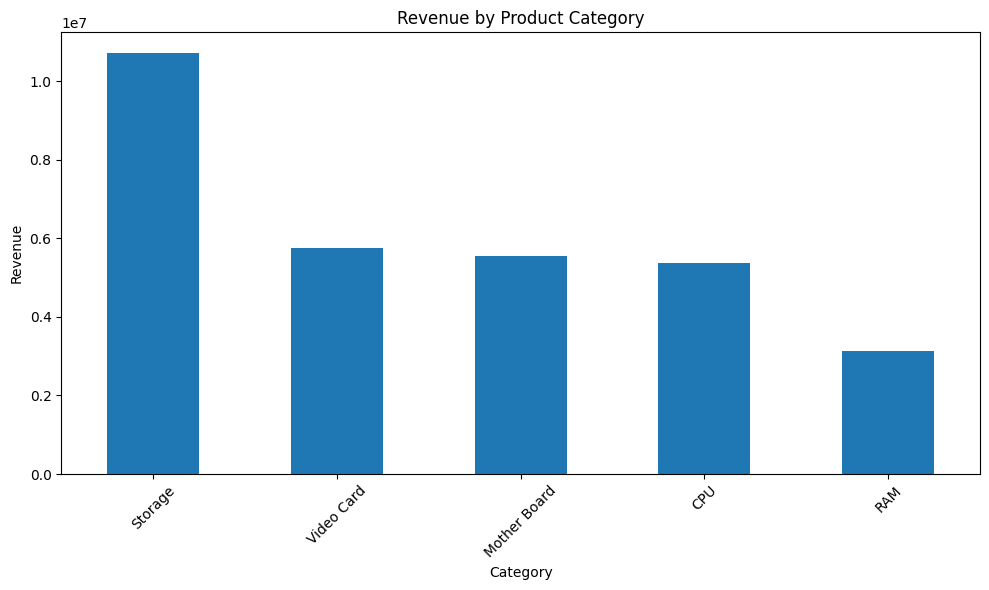

In [18]:
plt.figure(figsize=(10,6))

category_analysis['Revenue'].plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [20]:
fast_moving = (
    df.groupby('ProductName')
      .agg(
          Units_Sold=('OrderItemQuantity', 'sum'),
          Orders=('ProductName', 'count'),
          Revenue=('Revenue', 'sum')
      )
      .sort_values('Units_Sold', ascending=False)
      .head(10)
)

fast_moving

,Units_Sold,Orders,Revenue
ProductName,,,
G.Skill Ripjaws V Series,1234,14,1063369.12
G.Skill Trident Z,922,10,903422.14
Corsair Dominator Platinum,757,10,634488.39
Corsair Vengeance LPX,566,8,259099.96
Kingston,408,5,288194.14
Crucial,374,4,225026.02
Asus PRIME X299-A,284,2,255873.16
PNY SSD9SC240GMDA-RB,262,2,683691.83
Intel Xeon E5-2695 V4,259,2,22107.41


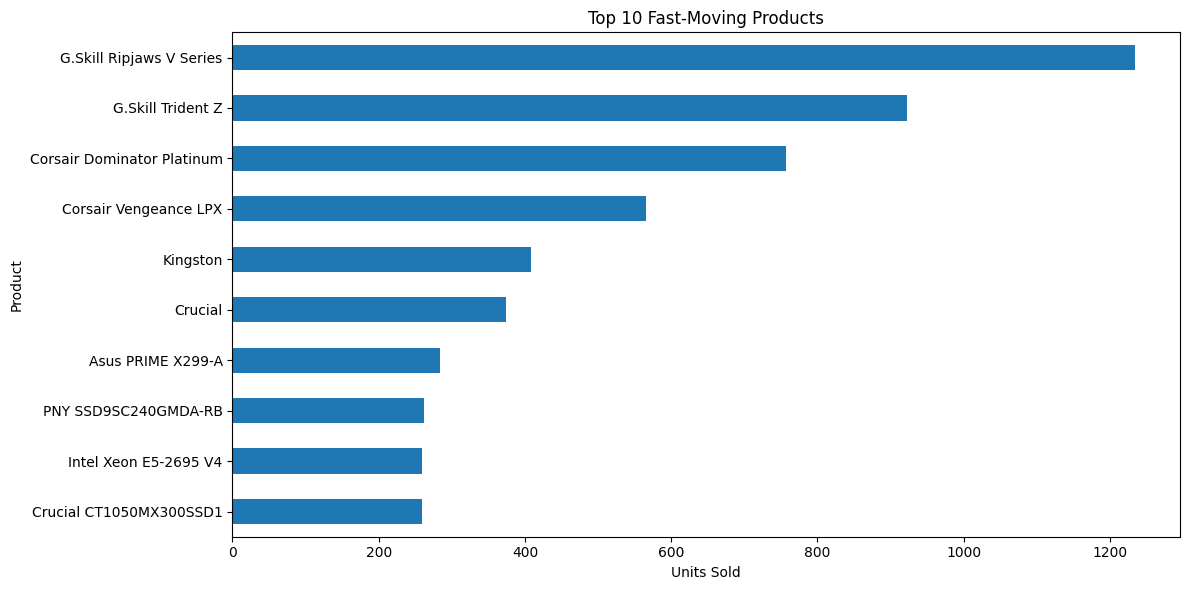

In [21]:
plt.figure(figsize=(12,6))

fast_moving['Units_Sold'].sort_values().plot(kind='barh')

plt.title('Top 10 Fast-Moving Products')
plt.xlabel('Units Sold')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

In [22]:
slow_moving = (
    df.groupby('ProductName')
      .agg(
          Units_Sold=('OrderItemQuantity', 'sum'),
          Orders=('ProductName', 'count'),
          Revenue=('Revenue', 'sum')
      )
      .sort_values('Units_Sold', ascending=True)
      .head(10)
)

slow_moving

,Units_Sold,Orders,Revenue
ProductName,,,
Asus MAXIMUS VIII EXTREME/ASSEMBLY,33,1,23561.67
ATI FirePro W9000,34,1,25499.66
EVGA 06G-P4-4998-KR,34,1,9111.66
Asus RAMPAGE V EXTREME,35,1,4784.15
Gigabyte GV-N108TAORUS X-11GD,35,1,3114.65
Adata XPG (AX3U1600W4G11-RD) 4GB,37,1,9915.63
Silicon Power (SP008GBLFU240B02) 8GB DDR4,37,1,19239.63
Intel Core i7-6900K,38,1,25080.00
AMD Opteron 6378,38,1,25877.62


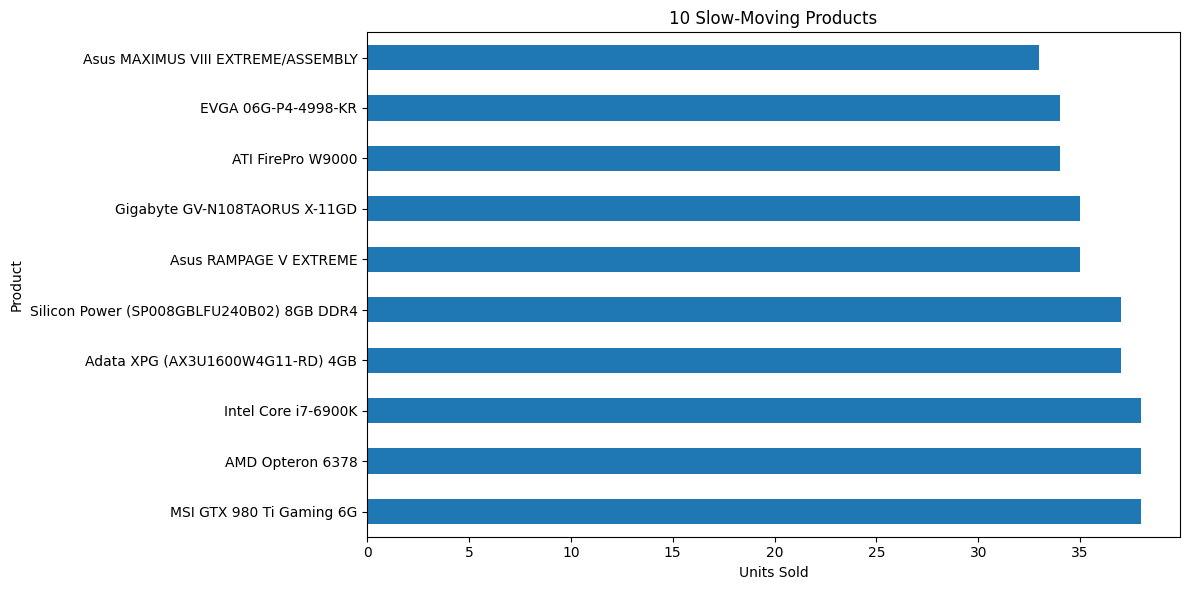

In [23]:
plt.figure(figsize=(12,6))

slow_moving['Units_Sold'].sort_values(ascending=False).plot(kind='barh')

plt.title('10 Slow-Moving Products')
plt.xlabel('Units Sold')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

In [24]:
monthly_demand = (
    df.groupby(['Year', 'Month'])
      .agg(
          Units_Sold=('OrderItemQuantity', 'sum'),
          Orders=('ProductName', 'count'),
          Revenue=('Revenue', 'sum')
      )
      .reset_index()
)

monthly_demand

,Year,Month,Units_Sold,Orders,Revenue
0,2013,6,567,5,422714.63
1,2015,4,705,7,378220.83
2,2015,5,940,9,565169.36
3,2015,6,427,6,435613.46
4,2015,10,1332,15,1097945.92
5,2015,12,1188,14,926421.98
6,2016,2,1666,17,1402024.96
7,2016,5,711,7,700329.81
8,2016,6,2643,33,2150980.94
9,2016,7,208,3,144094.47


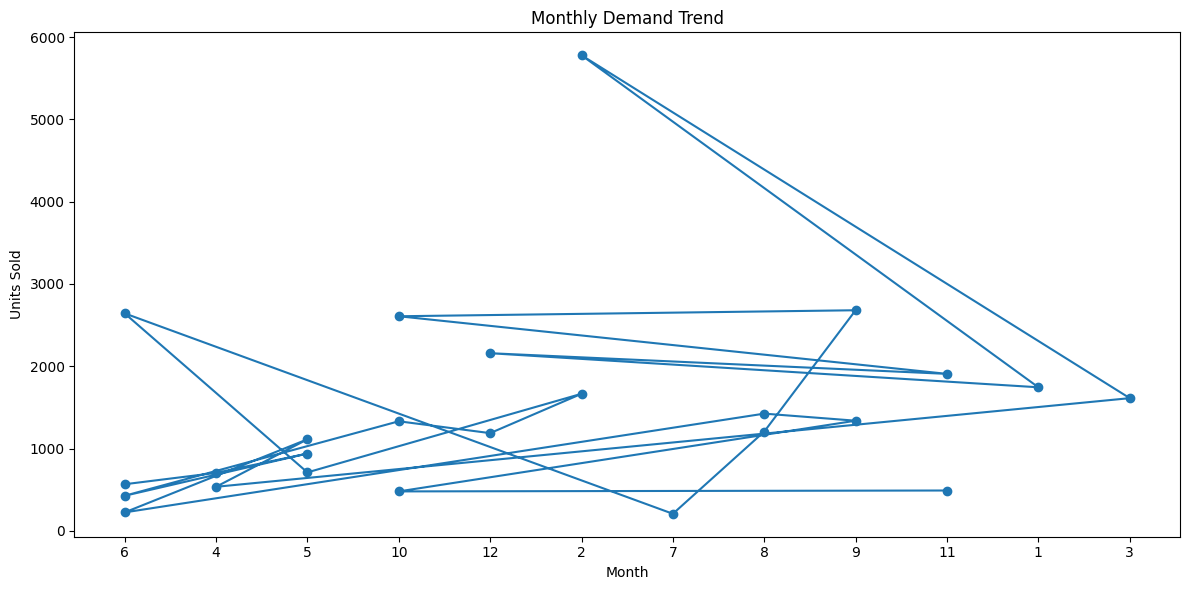

In [25]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_demand['Month'].astype(str),
    monthly_demand['Units_Sold'],
    marker='o'
)

plt.title('Monthly Demand Trend')
plt.xlabel('Month')
plt.ylabel('Units Sold')

plt.tight_layout()
plt.show()

In [26]:
status_analysis = (
    df.groupby('Status')
      .agg(
          Orders=('ProductName', 'count'),
          Units=('OrderItemQuantity', 'sum'),
          Revenue=('Revenue', 'sum')
      )
      .sort_values('Orders', ascending=False)
)

status_analysis

,Orders,Units,Revenue
Status,,,
Shipped,183,16827,14037758.60
Canceled,111,9456,8390685.96
Pending,106,9413,8091646.15


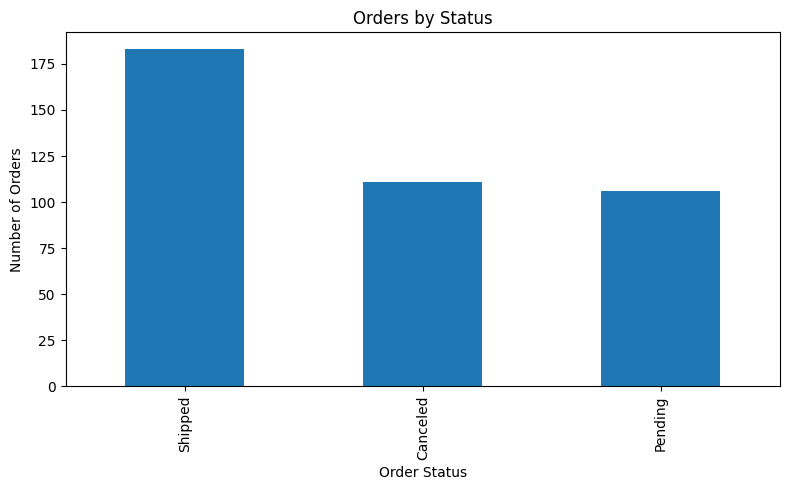

In [27]:
plt.figure(figsize=(8,5))

status_analysis['Orders'].plot(kind='bar')

plt.title('Orders by Status')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

In [28]:
canceled_orders = df[df['Status'] == 'Canceled']

print("Canceled Orders:", len(canceled_orders))
print(
    "Canceled Quantity:",
    canceled_orders['OrderItemQuantity'].sum()
)
print(
    "Potential Revenue:",
    round(canceled_orders['Revenue'].sum(), 2)
)

Canceled Orders: 111
Canceled Quantity: 9456
Potential Revenue: 8390685.96


In [29]:
canceled_by_product = (
    canceled_orders.groupby('ProductName')
    ['OrderItemQuantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

canceled_by_product

,OrderItemQuantity
ProductName,
G.Skill Trident Z,365
G.Skill Ripjaws V Series,307
ASRock EP2C602-4L/D16,191
Corsair Vengeance LPX,186
Corsair Dominator Platinum,173
Kingston,171
MSI Z270 XPOWER GAMING TITANIUM,165
Western Digital WD1003FZEX,157
MSI GAMING,152


In [30]:
warehouse_analysis = (
    df.groupby('WarehouseName')
      .agg(
          Orders=('ProductName', 'count'),
          Units_Sold=('OrderItemQuantity', 'sum'),
          Revenue=('Revenue', 'sum'),
          Profit=('Profit', 'sum')
      )
      .sort_values('Revenue', ascending=False)
)

warehouse_analysis

,Orders,Units_Sold,Revenue,Profit
WarehouseName,,,,
Mexico City,45,4382,4850774.35,11498.05
New Jersy,45,4017,3821020.40,8524.89
Sydney,45,3963,3704306.45,1442.32
Bombay,43,3709,3469394.07,7138.22
Seattle Washington,45,3738,3184680.56,6406.94
Toronto,44,3854,3097190.64,3817.83
Beijing,45,4030,2943211.19,10348.09
San Francisco,44,3758,2742251.82,12539.70
Southlake Texas,44,4245,2707261.23,14181.44


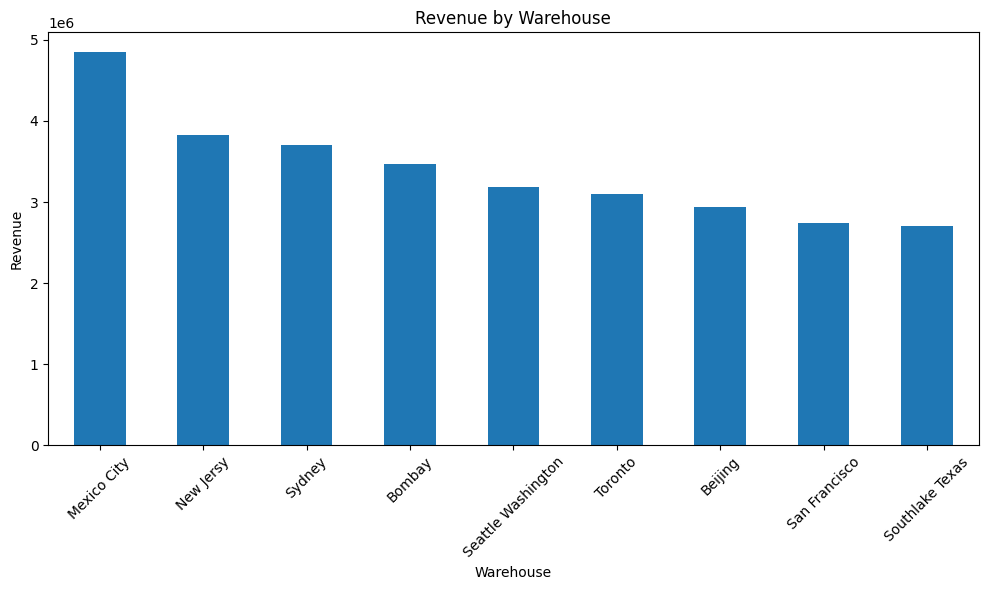

In [31]:
plt.figure(figsize=(10,6))

warehouse_analysis['Revenue'].plot(kind='bar')

plt.title('Revenue by Warehouse')
plt.xlabel('Warehouse')
plt.ylabel('Revenue')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [32]:
product_profit = (
    df.groupby('ProductName')
      .agg(
          Units_Sold=('OrderItemQuantity', 'sum'),
          Revenue=('Revenue', 'sum'),
          Profit=('Profit', 'sum')
      )
      .sort_values('Profit', ascending=False)
      .head(10)
)

product_profit

,Units_Sold,Revenue,Profit
ProductName,,,
G.Skill RipjawsX (F3-1600C9Q-32GXM) DDR3 32 GB,149,307683.51,2770.00
A-DATA (AX4U300038G16-SRS) 8GB DDR4,133,99748.67,1990.00
G.Skill TridentX (F3-2400C10D-8GTX) DDR3 8GB,149,178798.51,1962.00
G.Skill Ripjaws V Series,1234,1063369.12,1833.04
Corsair Vengeance LPX (CMK16GX4M2B3000C15B) 16GB,45,1889.55,1749.00
Corsair Dominator Platinum,757,634488.39,1748.46
G.Skill Trident Z,922,903422.14,1674.84
Corsair Vengeance LPX,566,259099.96,1579.64
PNY VCQP6000-PB,46,76664.06,1441.00


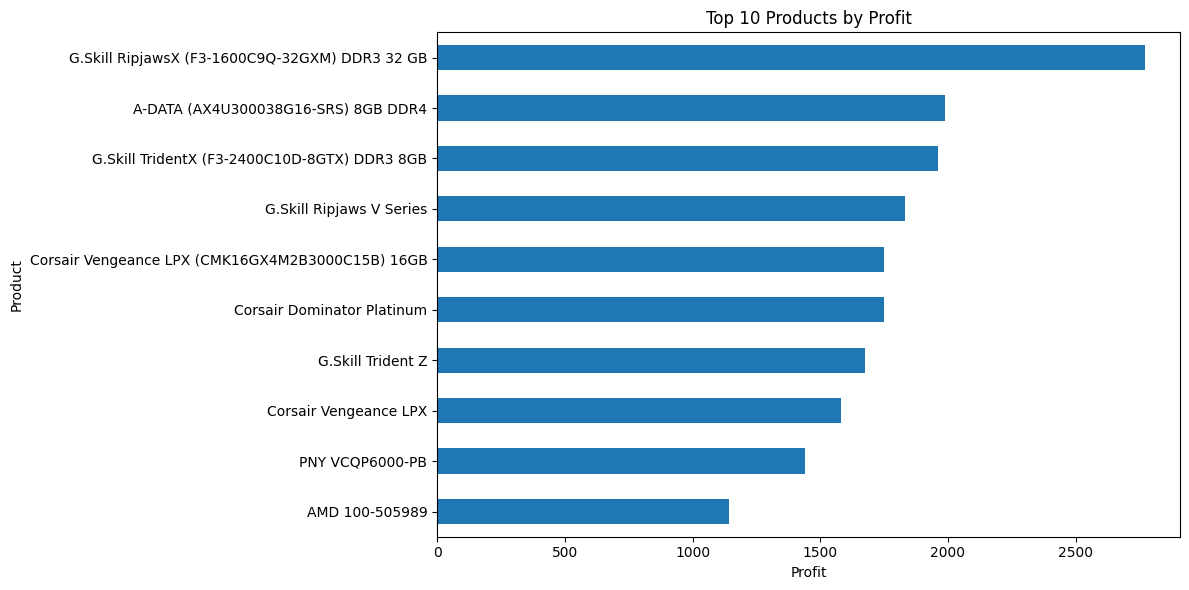

In [33]:
plt.figure(figsize=(12,6))

product_profit['Profit'].sort_values().plot(kind='barh')

plt.title('Top 10 Products by Profit')
plt.xlabel('Profit')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

In [34]:
product_status = (
    df.groupby('ProductName')
      .agg(
          Total_Orders=('ProductName', 'count'),
          Units_Sold=('OrderItemQuantity', 'sum'),
          Revenue=('Revenue', 'sum')
      )
)

product_status['Avg_Units_Per_Order'] = (
    product_status['Units_Sold'] /
    product_status['Total_Orders']
)

product_status.sort_values(
    'Units_Sold',
    ascending=False
).head(15)

,Total_Orders,Units_Sold,Revenue,Avg_Units_Per_Order
ProductName,,,,
G.Skill Ripjaws V Series,14,1234,1063369.12,88.142857
G.Skill Trident Z,10,922,903422.14,92.200000
Corsair Dominator Platinum,10,757,634488.39,75.700000
Corsair Vengeance LPX,8,566,259099.96,70.750000
Kingston,5,408,288194.14,81.600000
Crucial,4,374,225026.02,93.500000
Asus PRIME X299-A,2,284,255873.16,142.000000
PNY SSD9SC240GMDA-RB,2,262,683691.83,131.000000
Intel Xeon E5-2695 V4,2,259,22107.41,129.500000
